In [1]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================
# LOAD DATASET
# ================================

# Change this path if needed


df = pd.read_csv("/content/ai4i2020.csv")

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# ================================
# BASIC CLEANING
# ================================

# Drop unnecessary columns
df = df.drop(columns=["UDI", "Product ID"])

# Check nulls
print(df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Duplicates: 0


In [4]:
# ================================
# FEATURE ENGINEERING
# ================================

# Convert Type → Numeric
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

# -------------------------------
# Temperature Features
# -------------------------------
df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Temp_Ratio"] = df["Process temperature [K]"] / df["Air temperature [K]"]
df["Temp_Avg"] = (df["Process temperature [K]"] + df["Air temperature [K]"]) / 2

# -------------------------------
# Load & Stress Features
# -------------------------------
df["Stress"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df["Power"] = (df["Torque [Nm]"] * df["Rotational speed [rpm]"]) / 9550
df["Thermal_Stress"] = df["Process temperature [K]"] * df["Torque [Nm]"]

# -------------------------------
# Wear Features
# -------------------------------
df["Wear_Rate"] = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)
df["Wear_Impact"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df["Normalized_Wear"] = df["Tool wear [min]"] / df["Tool wear [min]"].max()

# -------------------------------
# Ratio Features
# -------------------------------
df["Torque_Speed_Ratio"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
df["Efficiency"] = df["Rotational speed [rpm]"] / (df["Torque [Nm]"] + 1)

# -------------------------------
# Risk & Flags
# -------------------------------
df["High_Temp_Flag"] = (df["Process temperature [K]"] > 310).astype(int)
df["High_Wear_Flag"] = (df["Tool wear [min]"] > 150).astype(int)
df["High_Torque_Flag"] = (df["Torque [Nm]"] > 50).astype(int)

df["Risk_Score"] = (
    df["Tool wear [min]"] * 0.4 +
    df["Torque [Nm]"] * 0.3 +
    df["Temp_Diff"] * 0.3
)

# -------------------------------
# Drop failure subtypes
# -------------------------------
df = df.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

print("Feature Engineering Completed ✅")

Feature Engineering Completed ✅


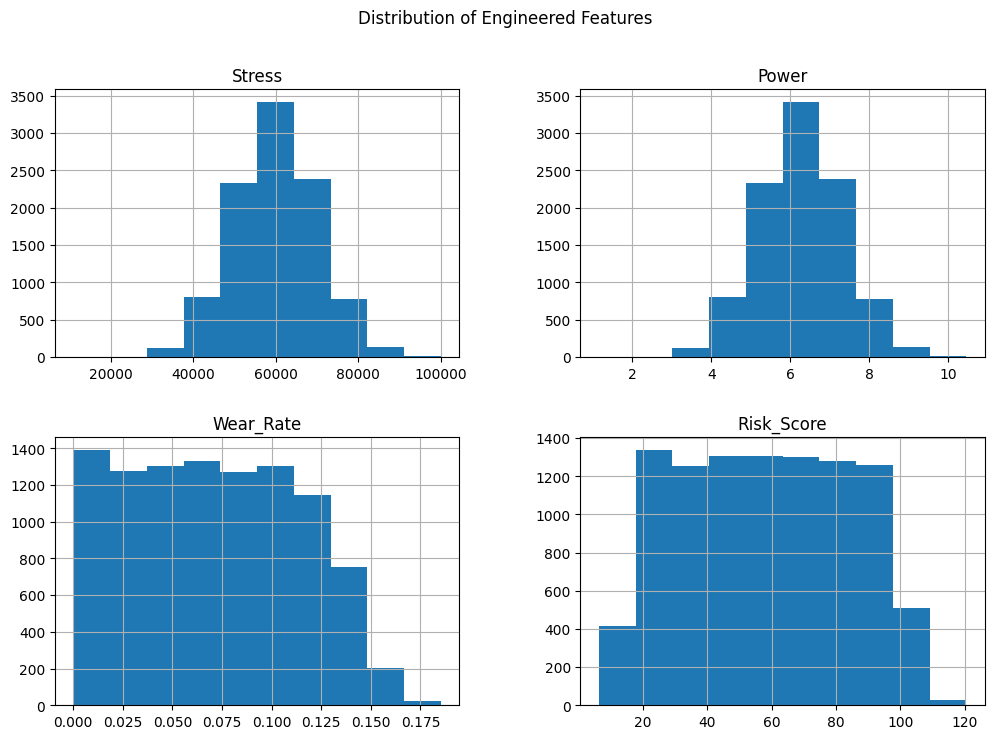

In [5]:
df[["Stress", "Power", "Wear_Rate", "Risk_Score"]].hist(figsize=(12,8))
plt.suptitle("Distribution of Engineered Features")
plt.show()

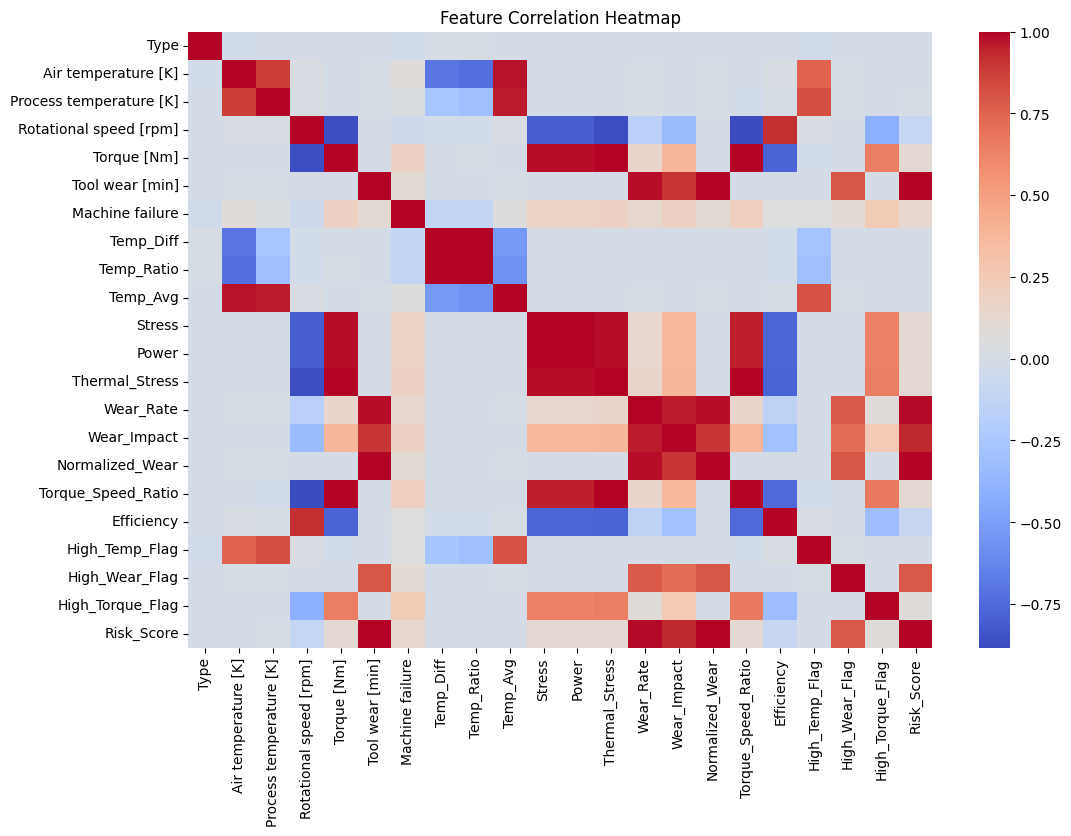

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

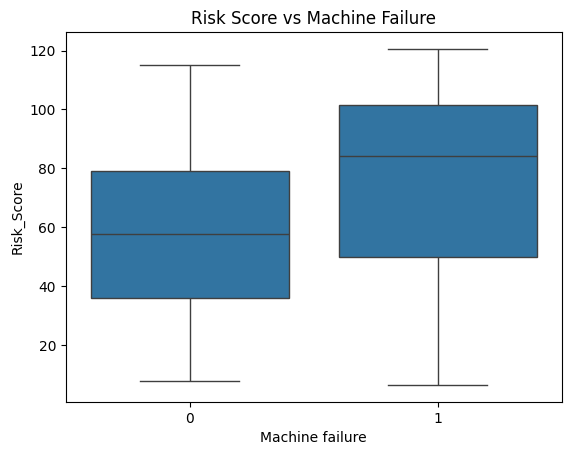

In [7]:
sns.boxplot(x=df["Machine failure"], y=df["Risk_Score"])
plt.title("Risk Score vs Machine Failure")
plt.show()

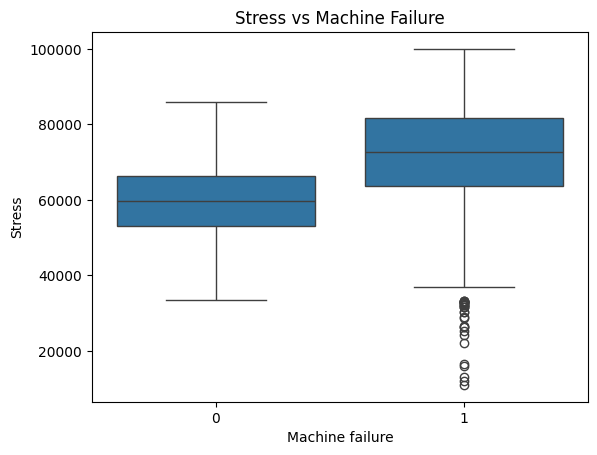

In [8]:
sns.boxplot(x=df["Machine failure"], y=df["Stress"])
plt.title("Stress vs Machine Failure")
plt.show()

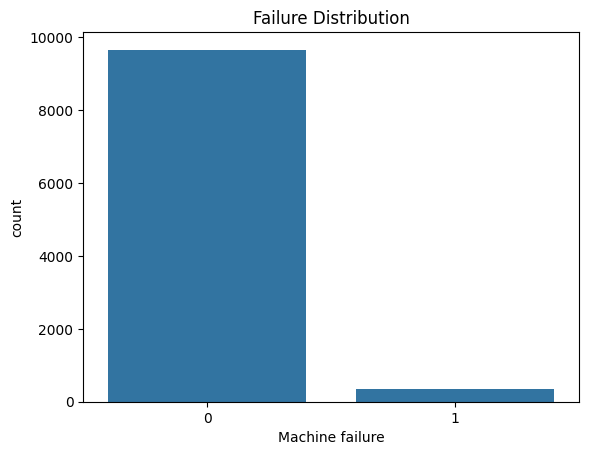

In [9]:
sns.countplot(x=df["Machine failure"])
plt.title("Failure Distribution")
plt.show()

In [13]:
print("Final Columns:\n", df.columns)
print("\nDataset Shape:", df.shape)

df.head()

Final Columns:
 Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Temp_Diff', 'Temp_Ratio', 'Temp_Avg', 'Stress',
       'Power', 'Thermal_Stress', 'Wear_Rate', 'Wear_Impact',
       'Normalized_Wear', 'Torque_Speed_Ratio', 'Efficiency', 'High_Temp_Flag',
       'High_Wear_Flag', 'High_Torque_Flag', 'Risk_Score'],
      dtype='object')

Dataset Shape: (10000, 22)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Temp_Ratio,Temp_Avg,...,Thermal_Stress,Wear_Rate,Wear_Impact,Normalized_Wear,Torque_Speed_Ratio,Efficiency,High_Temp_Flag,High_Wear_Flag,High_Torque_Flag,Risk_Score
0,1,298.1,308.6,1551,42.8,0,0,10.5,1.035223,303.35,...,13208.08,0.000000,0.0,0.000000,0.027577,35.410959,0,0,0,15.99
1,0,298.2,308.7,1408,46.3,3,0,10.5,1.035211,303.45,...,14292.81,0.002129,138.9,0.011858,0.032860,29.767442,0,0,0,18.24
2,0,298.1,308.5,1498,49.4,5,0,10.4,1.034888,303.30,...,15239.90,0.003336,247.0,0.019763,0.032955,29.722222,0,0,0,19.94
3,0,298.2,308.6,1433,39.5,7,0,10.4,1.034876,303.40,...,12189.70,0.004881,276.5,0.027668,0.027545,35.382716,0,0,0,17.77
4,0,298.2,308.7,1408,40.0,9,0,10.5,1.035211,303.45,...,12348.00,0.006388,360.0,0.035573,0.028389,34.341463,0,0,0,18.75


In [11]:
# Create folder if not exists
os.makedirs("processed_data", exist_ok=True)

df.to_csv("processed_data/ai4i2020_feature_engineered.csv", index=False)

print("✅ Feature Engineered Dataset Saved Successfully!")

✅ Feature Engineered Dataset Saved Successfully!


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
